In [9]:
import spikeinterface.full as si
from spikeinterface.sorters import get_default_sorter_params, get_sorter_params_description
import probeinterface as pi
from spikeinterface_gui import run_mainwindow
from pathlib import Path
import json
import woodsort
import warnings


In [10]:
# Spike sorting pipeline for the H7100 dataset
# Experimenter: Trisha Narayanan 
# Acquired: Dec 2024 - May 2025

### Parameters set manually ### 

# path to the recording folder (the folder containing the OpenEphys folder YYYY-MM-DD_hh-mm-ss)
#recfolder_path ='/home/avadher/SIDB_Datastore/Trisha/Raw/H7100/H7113/H7113-250604'

run_spike_sorting = True # set to True if you want to re-run sorting and analyzer, False if using previously saved analyzer

#data_path = '/home/avadher/Data/Adrian/H7113-250604/'
data_path = '/home/avadher/Data/Adrian/H7113-250604/'
# set parameters for probe
shank_groups = [0, 1] # specify which groups in the xml file are shanks to be sorted (0-base)
probe_manufacturer = "cambridgeneurotech"
probe_name = "ASSY-156-H7" 

# set parameters for spike sorting
sorter = "mountainsort5"
n_jobs = 12  # number of CPU cores to run everything on 
analyzer_metrics_path = 'params/default_analyzer_metrics.json' # list of metrics for Analyzer to compute 

# set parameters for tracking 
ttl_channel = 64 # channel in DAT file where camera TTL pulses are registered (0-base)
column_names=['x_left','y_left','x_right','y_right']  # keep the same names but change order as recorded
pixel_width = 0.1304  # size of one pixel in cm, get from video by typing pixelwidth in terminal 
min_spacing = 3  # minimum spacing between two LEDs in cm 
max_spacing = 8  # maximum spacing between two LEDs in cm 


### parameters set automatically ### 

# Set paths 
data_path = Path(data_path)
analyzer_metrics_path = Path(woodsort.__file__).parent / analyzer_metrics_path
session_name = data_path.name
processed_folder_name = 'Processed'
spikesorting_folder_name = f"{session_name}_sorting_{sorter}"
spikesorting_path = data_path / spikesorting_folder_name
analyzer_folder_name = f"{session_name}_analyzer_{sorter}"
analyzer_path = data_path / analyzer_folder_name
curation_path = analyzer_path / 'spikeinterface_gui/curation_data.json'

# Set the number for cores for parallel processing 
si.set_global_job_kwargs(n_jobs=n_jobs) 

# Ignore annoying warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


Using XML file: /home/avadher/Data/Adrian/H7113-250604/2025-06-04_14-46-12/Record Node 101/experiment1/recording1/continuous/Acquisition_Board-100.Rhythm Data/continuous.xml
Probe updated with Neuroscope mapping
Applying high-pass filter (300-6000 Hz)...
Detecting and removing bad channels...
Bad channel IDs (0-based Neuroscope index): [0, 16]
Channel mapping saved to /home/avadher/Data/Adrian/H7113-250604/ChannelMapping.csv 

write_binary_recording 
engine=process - n_jobs=12 - samples_per_chunk=30,000 - chunk_memory=3.43 MiB - total_memory=41.20 MiB - chunk_duration=1.00s
Using training recording of duration 300 sec with the sampling mode uniform
*** MS5 Elapsed time for SCHEME2 get_sampled_recording_for_training: 0.190 seconds ***
Running phase 1 sorting
Number of channels: 30
Number of timepoints: 9000000
Sampling frequency: 30000.0 Hz
Channel 0: [  4.5 450. ]
Channel 1: [  6. 600.]
Channel 2: [  2. 200.]
Channel 3: [  7.5 750. ]
Channel 4: [ 0.5 50. ]
Channel 5: [  7. 700.]
Channe

estimate_sparsity (workers: 12 processes):   0%|          | 0/649 [00:00<?, ?it/s]

compute_waveforms (workers: 12 processes):   0%|          | 0/649 [00:00<?, ?it/s]

noise_level (workers: 12 processes):   0%|          | 0/20 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/91 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/91 [00:00<?, ?it/s]

Compute : spike_amplitudes + spike_locations (workers: 12 processes):   0%|          | 0/649 [00:00<?, ?it/s]

/home/avadher/.conda/envs/woodsort/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/avadher/.conda/envs/woodsort/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/avadher/.conda/envs/woodsort/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


noise_level (workers: 12 processes):   0%|          | 0/20 [00:00<?, ?it/s]

calculate_pc_metrics:   0%|          | 0/91 [00:00<?, ?it/s]

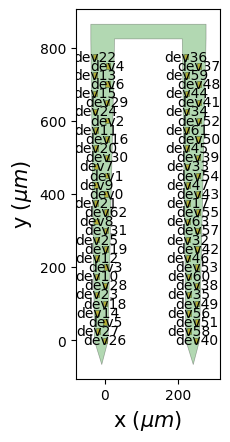

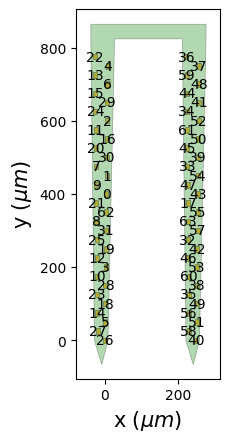

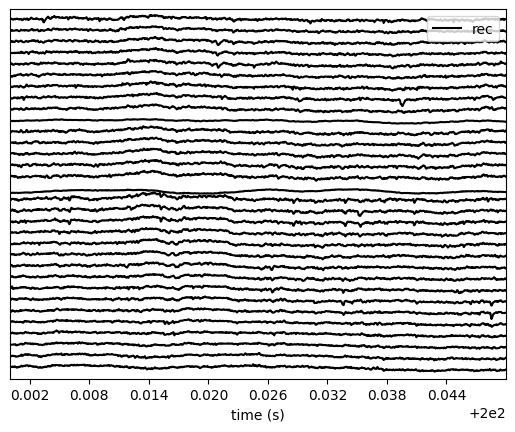

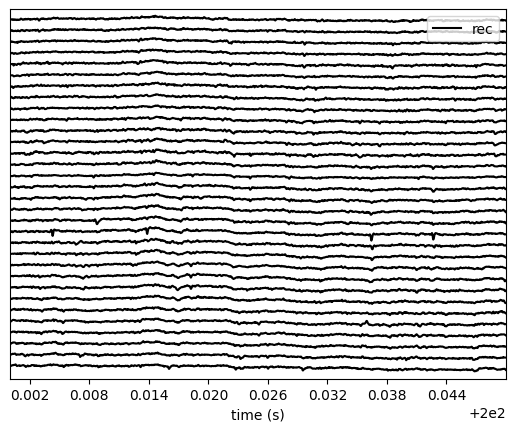

In [13]:
### Spike sorting ### 

if run_spike_sorting:
    
    # Load recording and probe, preprocess and fill channel indices from Neuroscope
    recording = si.read_openephys(data_path, stream_id='0')
    probe = pi.get_probe(manufacturer=probe_manufacturer, probe_name=probe_name) # pi.list_all_probes() to list all probes 
    
    recording = woodsort.openephys.process_openephys_with_neuroscope(
        recording=recording, 
        probe=probe,
        session_path=data_path,
        shank_groups=shank_groups, 
        remove_bad_channels=True,  # SET TO TRUE
        plot_probe=True,
        plot_range=[200, 200.05])
    
    # Run spike sorting
    sorting = si.run_sorter(
        recording=recording, 
        sorter_name=sorter, 
        remove_existing_folder=True, 
        folder=spikesorting_path)
    
    ## Compute analyzer
    analyzer_metrics = json.load(open(analyzer_metrics_path))
    si.create_sorting_analyzer(
        recording=recording,
        sorting=sorting,
        format="binary_folder",
        folder=analyzer_path,
        overwrite=True,
    ).compute(analyzer_metrics)


In [14]:
### Manual curation ###

analyzer = si.load_sorting_analyzer(analyzer_path)
run_mainwindow(analyzer, mode="desktop", curation=True)


In [15]:
print(analyzer.recording.get_property("channel_name"))


['CH2' 'CH3' 'CH4' 'CH5' 'CH6' 'CH7' 'CH8' 'CH9' 'CH10' 'CH11' 'CH12'
 'CH13' 'CH14' 'CH15' 'CH16' 'CH19' 'CH20' 'CH21' 'CH22' 'CH23' 'CH24'
 'CH25' 'CH26' 'CH27' 'CH28' 'CH29' 'CH30' 'CH31' 'CH32' 'CH63' 'CH18'
 'CH33' 'CH34' 'CH35' 'CH36' 'CH37' 'CH38' 'CH39' 'CH40' 'CH41' 'CH42'
 'CH43' 'CH44' 'CH45' 'CH46' 'CH47' 'CH48' 'CH49' 'CH50' 'CH51' 'CH52'
 'CH53' 'CH54' 'CH55' 'CH56' 'CH57' 'CH58' 'CH59' 'CH60' 'CH61' 'CH62'
 'CH64']


Extracting start and end times: /home/avadher/Data/Adrian/H7113-250604/2025-06-04_14-46-12/Record Node 101/experiment1/recording1

Epoch timestamps saved to: /home/avadher/Data/Adrian/H7113-250604/EpochTimestamps.csv

Extracting event times: /home/avadher/Data/Adrian/H7113-250604/2025-06-04_14-46-12/Record Node 101/experiment1/recording1

Event timestamps saved to: /home/avadher/Data/Adrian/H7113-250604/EventTimestamps.csv


Sync metadata written to: /home/avadher/Data/Adrian/H7113-250604/MetadataOpenephys.txt

Aligning Bonsai tracking data...

Recording path: /home/avadher/Data/Adrian/H7113-250604/2025-06-04_14-46-12/Record Node 101/experiment1/recording1
TTL pulses:         25592
Bonsai frames:      25591
Trimming 1 extra TTL pulses at the end
Tracking saved to: /home/avadher/Data/Adrian/H7113-250604/TrackingAligned.csv

Tracking aligned.


Processing aligned tracking
5.7% frames removed due to LED spacing outside [3, 8] cm
Tracking saved to: /home/avadher/Data/Adrian/H7113-250604/Tr

Extracting LFP: 100%|██████████| 194/194 [00:27<00:00,  7.05it/s]



Done. Processed 1 recording folder(s).
Merged 1 LFP files into /home/avadher/Data/Adrian/H7113-250604/continuous.lfp.
Component LFP files removed.
Copied XML file.
LFP extraction done.



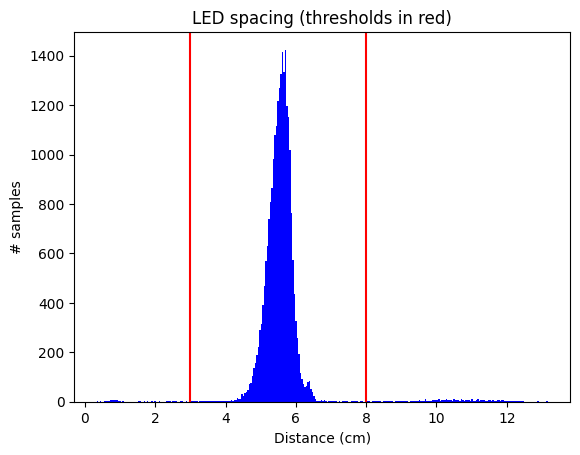

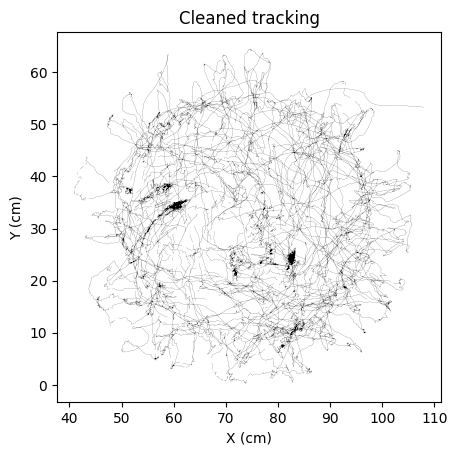

In [16]:
### Get other data from the recording ###

# get epochs
epochs = woodsort.openephys.get_epochs_openephys(
    data_path, 
    save_path =data_path)

# get events 
events = woodsort.openephys.get_events_openephys(
    data_path,
    epochs='all') # specify which epoch to extract events from (skip to extract from all epochs)

# get OpenEphys metadata
woodsort.openephys.get_metadata_openephys(
        data_path, 
        save_path =data_path)

# align tracking
aligned_tracking = woodsort.tracking.align_tracking_bonsai(
    recfolder_path=data_path, 
    ttl_channel=ttl_channel, 
    column_names=column_names, 
    save_path=data_path)

# process tracking
processed_tracking = woodsort.tracking.process_tracking_bonsai(
        aligned_tracking,   
        pixel_width=pixel_width,      # conversion factor: cm per pixel
        min_spacing=min_spacing,      # minimum allowed LED spacing (cm)
        max_spacing=max_spacing,  
        save_path=data_path,  # maximum allowed LED spacing (cm)
        plot=True)             # whether to show diagnostic plot

# Extract LFP
woodsort.lfp.extract_lfp_openephys(data_path)
